In [2]:
# =============================================================================
# MULTIPLE MYELOMA SURVIVAL — EXPLORATORY DATA ANALYSIS
# =============================================================================
# This notebook explores the clinical and gene expression data from GSE24080.
#
# Goals:
#   1. Understand the clinical characteristics of the 559 patients
#   2. Analyze the distribution of survival endpoints (OS, EFS)
#   3. Explore the gene expression data quality and distribution
#   4. Reduce dimensionality with PCA and UMAP to visualize patient clusters
#   5. Identify preliminary associations between expression and survival
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100



In [3]:
# =============================================================================
# DATA LOADING
# =============================================================================

# Clinical data
df_clinical = pd.read_csv('../data/clinical_data.csv')

# Expression matrix
df_expr = pd.read_csv('../data/expression_matrix.csv', index_col='sample_id')

print(f"Clinical data: {df_clinical.shape}")
print(f"Expression matrix: {df_expr.shape}")
print(f"\nClinical data preview:")
print(df_clinical.head())

Clinical data: (559, 7)
Expression matrix: (559, 21655)

Clinical data preview:
      split   age     sex  class_label  efs_24m  os_24m  sample_id
0  Training  53.4  female            1        0       0  GSM592391
1  Training  52.7  female            1        0       0  GSM592392
2  Training  62.0    male            1        0       0  GSM592393
3  Training  60.3    male            1        0       0  GSM592394
4  Training  66.9    male            1        0       0  GSM592395


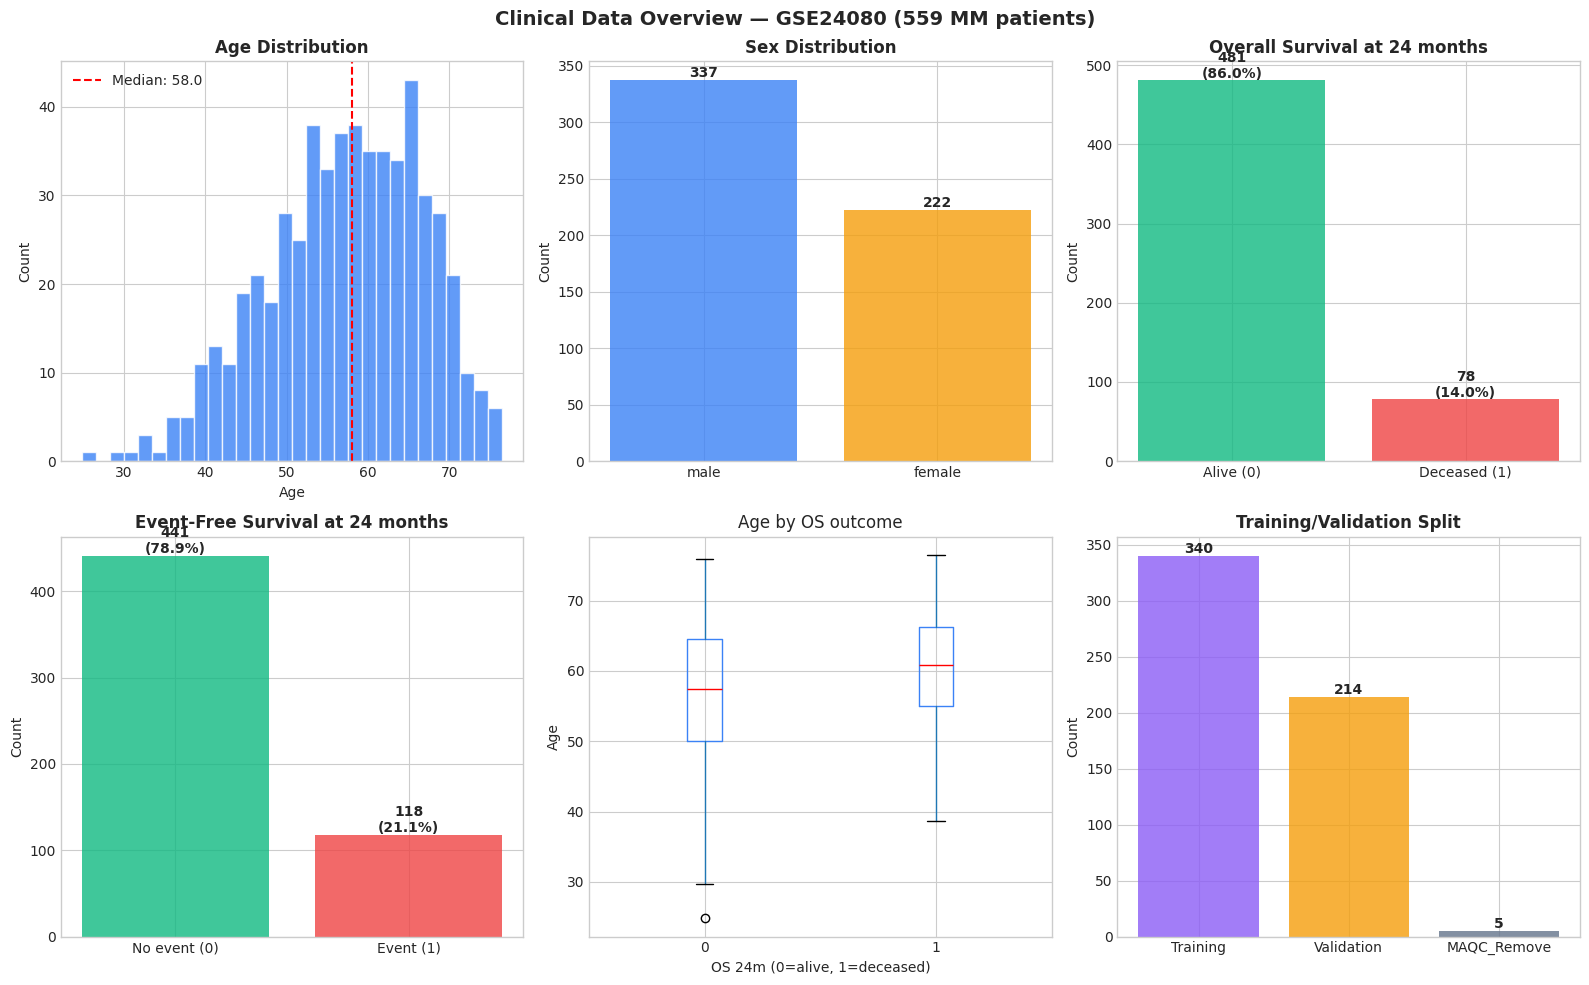


=== CLINICAL SUMMARY ===
Total patients: 559
Age: 57.2 ± 9.5 years (mean ± std)
Sex: 337 male (60.3%), 222 female (39.7%)
OS events: 78 (14.0%)
EFS events: 118 (21.1%)


In [4]:
# =============================================================================
# CLINICAL DATA ANALYSIS
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Age distribution
axes[0,0].hist(df_clinical['age'], bins=30, color='#3b82f6', alpha=0.8, edgecolor='white')
axes[0,0].set_title('Age Distribution', fontweight='bold')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')
axes[0,0].axvline(df_clinical['age'].median(), color='red', linestyle='--', 
                   label=f"Median: {df_clinical['age'].median():.1f}")
axes[0,0].legend()

# 2. Sex distribution
sex_counts = df_clinical['sex'].value_counts()
axes[0,1].bar(sex_counts.index, sex_counts.values, color=['#3b82f6', '#f59e0b'], alpha=0.8)
axes[0,1].set_title('Sex Distribution', fontweight='bold')
axes[0,1].set_ylabel('Count')
for i, v in enumerate(sex_counts.values):
    axes[0,1].text(i, v + 3, str(v), ha='center', fontweight='bold')

# 3. OS 24m distribution
os_counts = df_clinical['os_24m'].value_counts()
axes[0,2].bar(['Alive (0)', 'Deceased (1)'], os_counts.values, 
               color=['#10b981', '#ef4444'], alpha=0.8)
axes[0,2].set_title('Overall Survival at 24 months', fontweight='bold')
axes[0,2].set_ylabel('Count')
for i, v in enumerate(os_counts.values):
    axes[0,2].text(i, v + 3, f"{v}\n({v/len(df_clinical)*100:.1f}%)", 
                   ha='center', fontweight='bold')

# 4. EFS 24m distribution
efs_counts = df_clinical['efs_24m'].value_counts()
axes[1,0].bar(['No event (0)', 'Event (1)'], efs_counts.values,
               color=['#10b981', '#ef4444'], alpha=0.8)
axes[1,0].set_title('Event-Free Survival at 24 months', fontweight='bold')
axes[1,0].set_ylabel('Count')
for i, v in enumerate(efs_counts.values):
    axes[1,0].text(i, v + 3, f"{v}\n({v/len(df_clinical)*100:.1f}%)", 
                   ha='center', fontweight='bold')

# 5. Age by OS
df_clinical.boxplot(column='age', by='os_24m', ax=axes[1,1], 
                     boxprops=dict(color='#3b82f6'),
                     medianprops=dict(color='red'))
axes[1,1].set_title('Age by OS outcome', fontweight='bold')
axes[1,1].set_xlabel('OS 24m (0=alive, 1=deceased)')
axes[1,1].set_ylabel('Age')
plt.sca(axes[1,1])
plt.title('Age by OS outcome')

# 6. Training/Validation split
split_counts = df_clinical['split'].value_counts()
axes[1,2].bar(split_counts.index, split_counts.values, 
               color=['#8b5cf6', '#f59e0b', '#64748b'], alpha=0.8)
axes[1,2].set_title('Training/Validation Split', fontweight='bold')
axes[1,2].set_ylabel('Count')
for i, v in enumerate(split_counts.values):
    axes[1,2].text(i, v + 3, str(v), ha='center', fontweight='bold')

plt.suptitle('Clinical Data Overview — GSE24080 (559 MM patients)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/clinical_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== CLINICAL SUMMARY ===")
print(f"Total patients: {len(df_clinical)}")
print(f"Age: {df_clinical['age'].mean():.1f} ± {df_clinical['age'].std():.1f} years (mean ± std)")
print(f"Sex: {sex_counts['male']} male ({sex_counts['male']/len(df_clinical)*100:.1f}%), "
      f"{sex_counts['female']} female ({sex_counts['female']/len(df_clinical)*100:.1f}%)")
print(f"OS events: {df_clinical['os_24m'].sum()} ({df_clinical['os_24m'].mean()*100:.1f}%)")
print(f"EFS events: {df_clinical['efs_24m'].sum()} ({df_clinical['efs_24m'].mean()*100:.1f}%)")

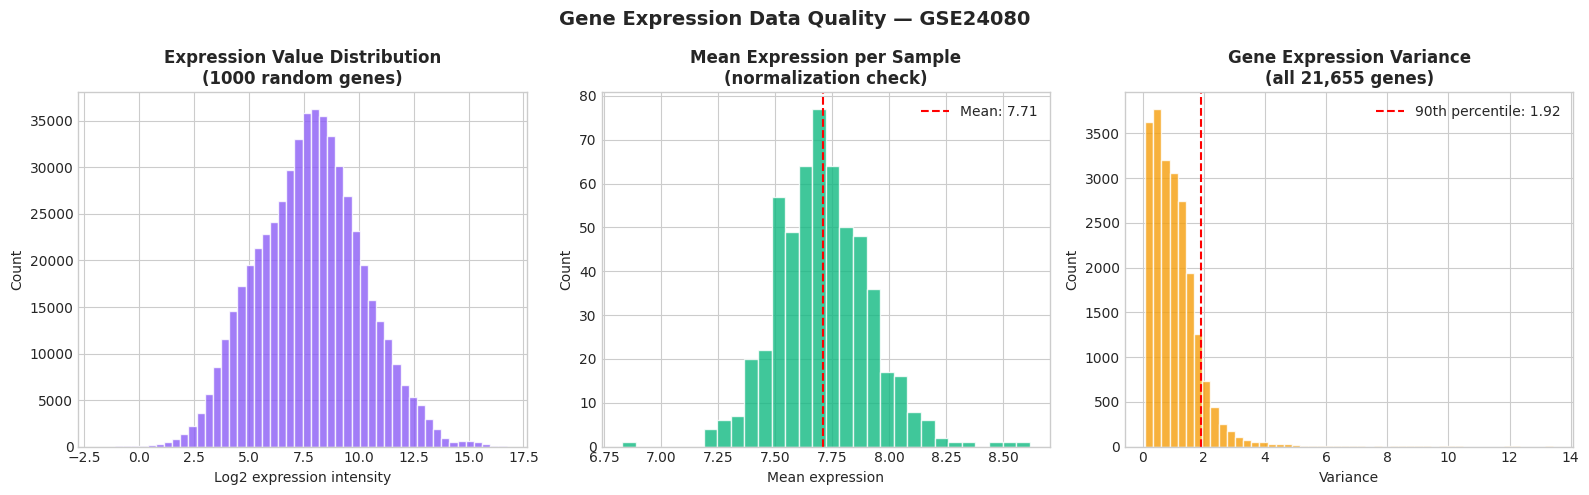


=== EXPRESSION DATA SUMMARY ===
Genes: 21655
Samples: 559
Expression range: [-3.78, 16.90]
Missing values: 0
Mean expression per sample: 7.71 ± 0.20

Top 10 most variable genes:
XIST      13.425718
EDNRB     12.092828
EIF1AY    11.975296
IGHD      11.875735
RGS13     10.446865
PMAIP1    10.220018
CCND2     10.014816
PTP4A3     9.768309
APP        9.409837
LAMP5      9.397394
dtype: float64


In [6]:
# =============================================================================
# EXPRESSION DATA QUALITY ANALYSIS
# =============================================================================
# This cell evaluates the technical quality of the gene expression data
# across three dimensions:
#
# 1. GLOBAL EXPRESSION DISTRIBUTION (plot 1)
#    Shows the distribution of all ~12M expression values (559 patients x
#    21,655 genes) flattened into a single histogram.
#    Each gene has its own natural expression range — a highly active gene
#    in plasma cells may have values of 12-14 while a lowly expressed gene
#    may be at 3-4. This is biologically normal.
#    We expect a roughly normal or bimodal distribution for well-normalized
#    Affymetrix data (log2 scale, typically range 2-14).
#
# 2. MEAN EXPRESSION PER SAMPLE (plot 2) — normalization check
#    For each of the 559 patients, computes the mean expression across all
#    21,655 genes. If all arrays were processed consistently, these 559 means
#    should be similar to each other (narrow distribution).
#    A patient with a very different mean would indicate a technical artifact
#    or poor quality array — not a biological difference.
#    This is a TECHNICAL check, not a biological one.
#
# 3. GENE EXPRESSION VARIANCE (plot 3) — gene informativeness
#    For each of the 21,655 genes, computes the variance across the 559
#    patients. Genes with HIGH variance are potentially informative —
#    they behave very differently across patients and may be linked to
#    prognosis. Genes with LOW variance are nearly constant across all
#    patients and carry little predictive value.
#    The top variable genes will be prioritized for modeling and SHAP
#    analysis.
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Distribution of expression values (sample of genes)
sample_genes = df_expr.sample(n=1000, axis=1, random_state=42)
axes[0].hist(sample_genes.values.flatten(), bins=50, 
             color='#8b5cf6', alpha=0.8, edgecolor='white')
axes[0].set_title('Expression Value Distribution\n(1000 random genes)', fontweight='bold')
axes[0].set_xlabel('Log2 expression intensity')
axes[0].set_ylabel('Count')

# 2. Mean expression per sample (should be similar across samples = good normalization)
sample_means = df_expr.mean(axis=1)
axes[1].hist(sample_means, bins=30, color='#10b981', alpha=0.8, edgecolor='white')
axes[1].set_title('Mean Expression per Sample\n(normalization check)', fontweight='bold')
axes[1].set_xlabel('Mean expression')
axes[1].set_ylabel('Count')
axes[1].axvline(sample_means.mean(), color='red', linestyle='--',
                label=f"Mean: {sample_means.mean():.2f}")
axes[1].legend()

# 3. Expression variance per gene (top variable genes)
gene_var = df_expr.var(axis=0)
axes[2].hist(gene_var, bins=50, color='#f59e0b', alpha=0.8, edgecolor='white')
axes[2].set_title('Gene Expression Variance\n(all 21,655 genes)', fontweight='bold')
axes[2].set_xlabel('Variance')
axes[2].set_ylabel('Count')
axes[2].axvline(gene_var.quantile(0.9), color='red', linestyle='--',
                label=f"90th percentile: {gene_var.quantile(0.9):.2f}")
axes[2].legend()

plt.suptitle('Gene Expression Data Quality — GSE24080', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/expression_quality.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n=== EXPRESSION DATA SUMMARY ===")
print(f"Genes: {df_expr.shape[1]}")
print(f"Samples: {df_expr.shape[0]}")
print(f"Expression range: [{df_expr.values.min():.2f}, {df_expr.values.max():.2f}]")
print(f"Missing values: {df_expr.isna().sum().sum()}")
print(f"Mean expression per sample: {sample_means.mean():.2f} ± {sample_means.std():.2f}")
print(f"\nTop 10 most variable genes:")
print(gene_var.nlargest(10))

In [7]:
# =============================================================================
# EXPRESSION DATA QUALITY — KEY FINDINGS
# =============================================================================
# Technical quality:
#   - Expression range [-3.78, 16.90] — expected for Affymetrix log2 data
#   - No missing values across 559 patients x 21,655 genes
#   - Mean expression per sample: 7.71 ± 0.20 — very low std indicates
#     consistent normalization across all 559 arrays
#
# Top most variable genes:
#   - XIST and EIF1AY: chromosome X and Y genes respectively — high variance
#     expected due to biological sex differences. Will need to be considered
#     carefully during modeling to avoid sex-driven bias.
#
#   - CCND2: cyclin D2 — known oncogene in MM, drives cell cycle progression.
#     High variance suggests different molecular subtypes in the cohort.
#
#   - PMAIP1: pro-apoptotic gene — relevant in treatment response in MM.
#     High variance may reflect differences in apoptotic pathway activity.
#
#   - IGHD: immunoglobulin delta — coherent with plasma cell biology.
#
#   - EDNRB: endothelin receptor type B — associated with plasma cell
#     migration and adhesion in bone marrow. Emerging evidence links it
#     to MM progression and treatment resistance. Potential novel biomarker
#     to investigate in SHAP analysis.
#
#   - APP: amyloid precursor protein — appears in some MM molecular subtypes.
# =============================================================================
print("Expression data quality findings documented.")

Expression data quality findings documented.


In [8]:
# =============================================================================
# DIMENSIONALITY REDUCTION — PCA
# =============================================================================
# With 21,655 genes per patient it is impossible to visualize the data
# directly. PCA (Principal Component Analysis) reduces the dimensionality
# by finding the directions of maximum variance in the data.
#
# We first filter to the top 5,000 most variable genes — a standard practice
# in genomics that removes noise from low-variance genes and speeds up
# computation while retaining the most informative signal.
#
# PCA output:
#   - Each patient is represented as a point in 2D space (PC1 vs PC2)
#   - Points close together = patients with similar gene expression profiles
#   - We color points by OS outcome, sex and age to identify patterns
# =============================================================================

# Filter to top 5000 most variable genes
gene_var = df_expr.var(axis=0)
top_genes = gene_var.nlargest(5000).index
df_expr_top = df_expr[top_genes]

print(f"Using top 5000 most variable genes for PCA")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_expr_top)

# PCA
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\nVariance explained by first 10 PCs:")
for i, var in enumerate(pca.explained_variance_ratio_):
    bar = '█' * int(var * 200)
    print(f"  PC{i+1}: {var*100:.1f}% {bar}")

print(f"\nTotal variance explained by PC1+PC2: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%")

Using top 5000 most variable genes for PCA

Variance explained by first 10 PCs:
  PC1: 11.0% ██████████████████████
  PC2: 3.8% ███████
  PC3: 2.4% ████
  PC4: 2.3% ████
  PC5: 1.6% ███
  PC6: 1.5% ██
  PC7: 1.3% ██
  PC8: 1.2% ██
  PC9: 1.2% ██
  PC10: 1.0% █

Total variance explained by PC1+PC2: 14.8%


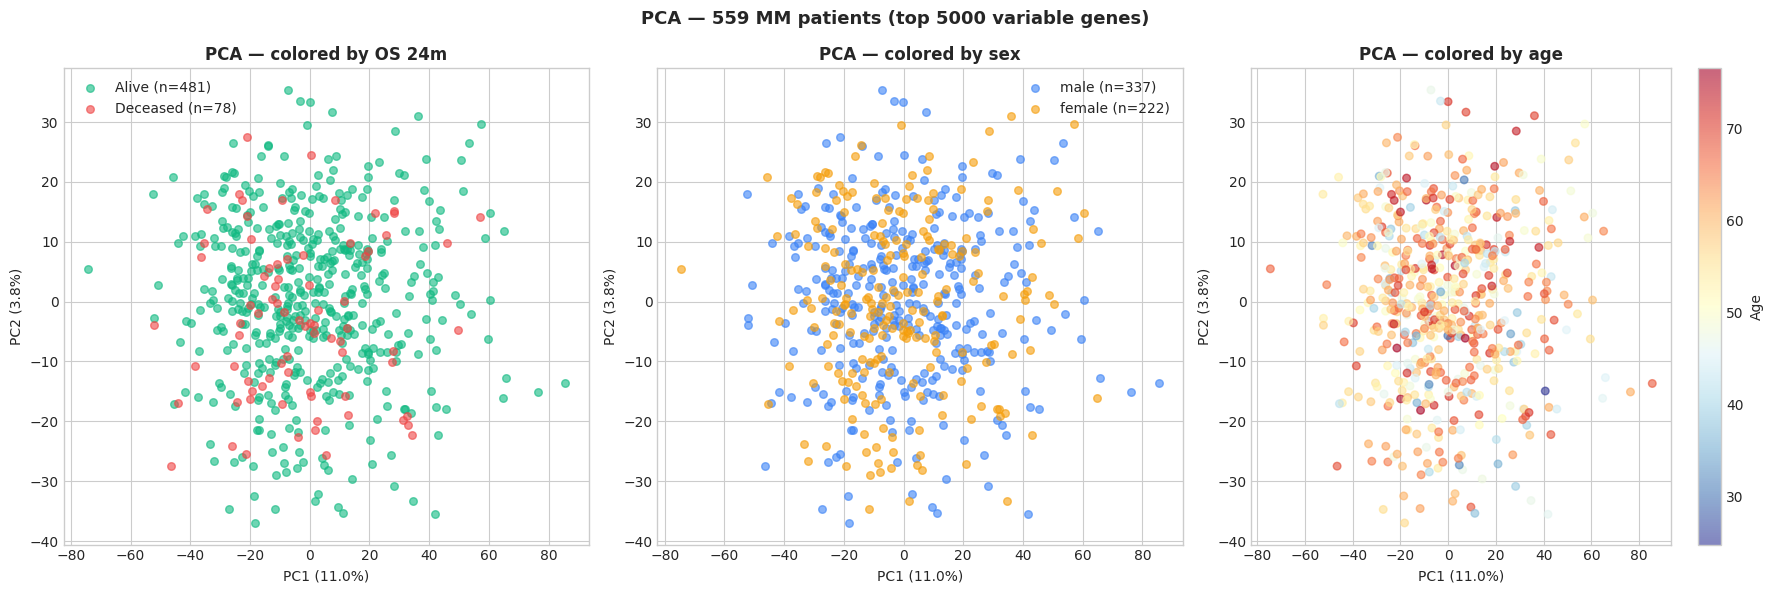

In [9]:
# =============================================================================
# PCA VISUALIZATION
# =============================================================================

# Merge PCA results with clinical data
df_pca = pd.DataFrame(X_pca[:, :2], columns=['PC1', 'PC2'])
df_pca['sample_id'] = df_expr.index
df_pca = df_pca.merge(df_clinical, on='sample_id')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Color by OS outcome
for outcome, color, label in [(0, '#10b981', 'Alive'), (1, '#ef4444', 'Deceased')]:
    mask = df_pca['os_24m'] == outcome
    axes[0].scatter(df_pca[mask]['PC1'], df_pca[mask]['PC2'],
                   c=color, alpha=0.6, s=30, label=f"{label} (n={mask.sum()})")
axes[0].set_title('PCA — colored by OS 24m', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# 2. Color by sex
for sex, color in [('male', '#3b82f6'), ('female', '#f59e0b')]:
    mask = df_pca['sex'] == sex
    axes[1].scatter(df_pca[mask]['PC1'], df_pca[mask]['PC2'],
                   c=color, alpha=0.6, s=30, label=f"{sex} (n={mask.sum()})")
axes[1].set_title('PCA — colored by sex', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend()

# 3. Color by age
scatter = axes[2].scatter(df_pca['PC1'], df_pca['PC2'],
                          c=df_pca['age'], cmap='RdYlBu_r',
                          alpha=0.6, s=30)
plt.colorbar(scatter, ax=axes[2], label='Age')
axes[2].set_title('PCA — colored by age', fontweight='bold')
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

plt.suptitle('PCA — 559 MM patients (top 5000 variable genes)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/pca_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# =============================================================================
# PCA LOADINGS — GENES CONTRIBUTING MOST TO EACH COMPONENT
# =============================================================================
# PCA loadings indicate how much each gene contributes to each principal
# component. High absolute loading = strong contribution to that PC.
# =============================================================================

# Get loadings
df_loadings = pd.DataFrame(
    pca.components_.T,
    index=top_genes,
    columns=[f'PC{i+1}' for i in range(10)]
)

# Top genes contributing to PC1 and PC2
for pc in ['PC1', 'PC2']:
    print(f"\n=== Top 15 genes contributing to {pc} ===")
    top_pos = df_loadings[pc].nlargest(15)
    top_neg = df_loadings[pc].nsmallest(15)
    print(f"\nPositive loadings (push right/up):")
    print(top_pos.to_string())
    print(f"\nNegative loadings (push left/down):")
    print(top_neg.to_string())


=== Top 15 genes contributing to PC1 ===

Positive loadings (push right/up):
RP11-108K3.2    0.029394
DLGAP1-AS2      0.028703
ANKRD31         0.028687
OXGR1           0.028499
LOC102724891    0.028185
HAS2            0.028165
ANXA10          0.027993
CDH12           0.027957
SAMM50          0.027878
CALCA           0.027846
C1orf180        0.027825
LECT2           0.027769
RMST            0.027763
LINC00559       0.027757
HTR3B           0.027735

Negative loadings (push left/down):
ZNF526     -0.027152
DDX23      -0.026529
ZNF3       -0.025949
RBM10      -0.025810
ASXL1      -0.024416
ZMYND19    -0.023930
LMNB2      -0.023850
POLDIP2    -0.023411
LZTFL1     -0.022992
C16orf13   -0.022975
SAC3D1     -0.022913
ZNF576     -0.022893
EXOSC4     -0.022886
EXOSC2     -0.022715
RBM17      -0.022529

=== Top 15 genes contributing to PC2 ===

Positive loadings (push right/up):
LENG9         0.049756
SHISA9        0.048147
DGCR10        0.044664
TLE6          0.044309
C2orf57       0.044262
TU

In [11]:
# =============================================================================
# GENE CO-EXPRESSION ANALYSIS
# =============================================================================
# Genes that vary similarly across patients are likely involved in the same
# biological pathway and are therefore redundant from a predictive standpoint.
#
# Approach:
#   1. Compute correlation matrix between top 5000 most variable genes
#   2. Hierarchical clustering to identify groups of co-expressed genes
#   3. Visualize with clustermap (heatmap + dendrogram)
#
# This analysis will help us:
#   - Identify redundant genes that can be removed
#   - Discover biological pathways active in MM
#   - Reduce dimensionality in a biologically meaningful way
# =============================================================================

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

print("Computing gene correlation matrix (5000 x 5000)... this may take a few minutes")

# Compute correlation matrix between genes (transpose so genes are rows)
df_top = df_expr[top_genes]
corr_matrix = df_top.corr()

print(f"Correlation matrix shape: {corr_matrix.shape}")
print(f"Memory usage: {corr_matrix.memory_usage(deep=True).sum() / 1e6:.1f} MB")

# Hierarchical clustering
print("\nClustering genes...")
distance_matrix = pdist(corr_matrix.values, metric='euclidean')
linkage_matrix = linkage(distance_matrix, method='ward')

# Assign clusters
n_clusters = 20
cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

df_gene_clusters = pd.DataFrame({
    'gene': top_genes,
    'cluster': cluster_labels
})

print(f"\nGene clusters (n={n_clusters}):")
print(df_gene_clusters['cluster'].value_counts().sort_index())

Computing gene correlation matrix (5000 x 5000)... this may take a few minutes
Correlation matrix shape: (5000, 5000)
Memory usage: 200.4 MB

Clustering genes...

Gene clusters (n=20):
cluster
1     251
2     368
3     553
4     238
5     158
6     360
7     227
8     137
9     178
10    297
11    105
12    127
13    360
14    224
15    199
16    146
17    193
18    403
19    116
20    360
Name: count, dtype: int64


<Figure size 1600x1000 with 0 Axes>

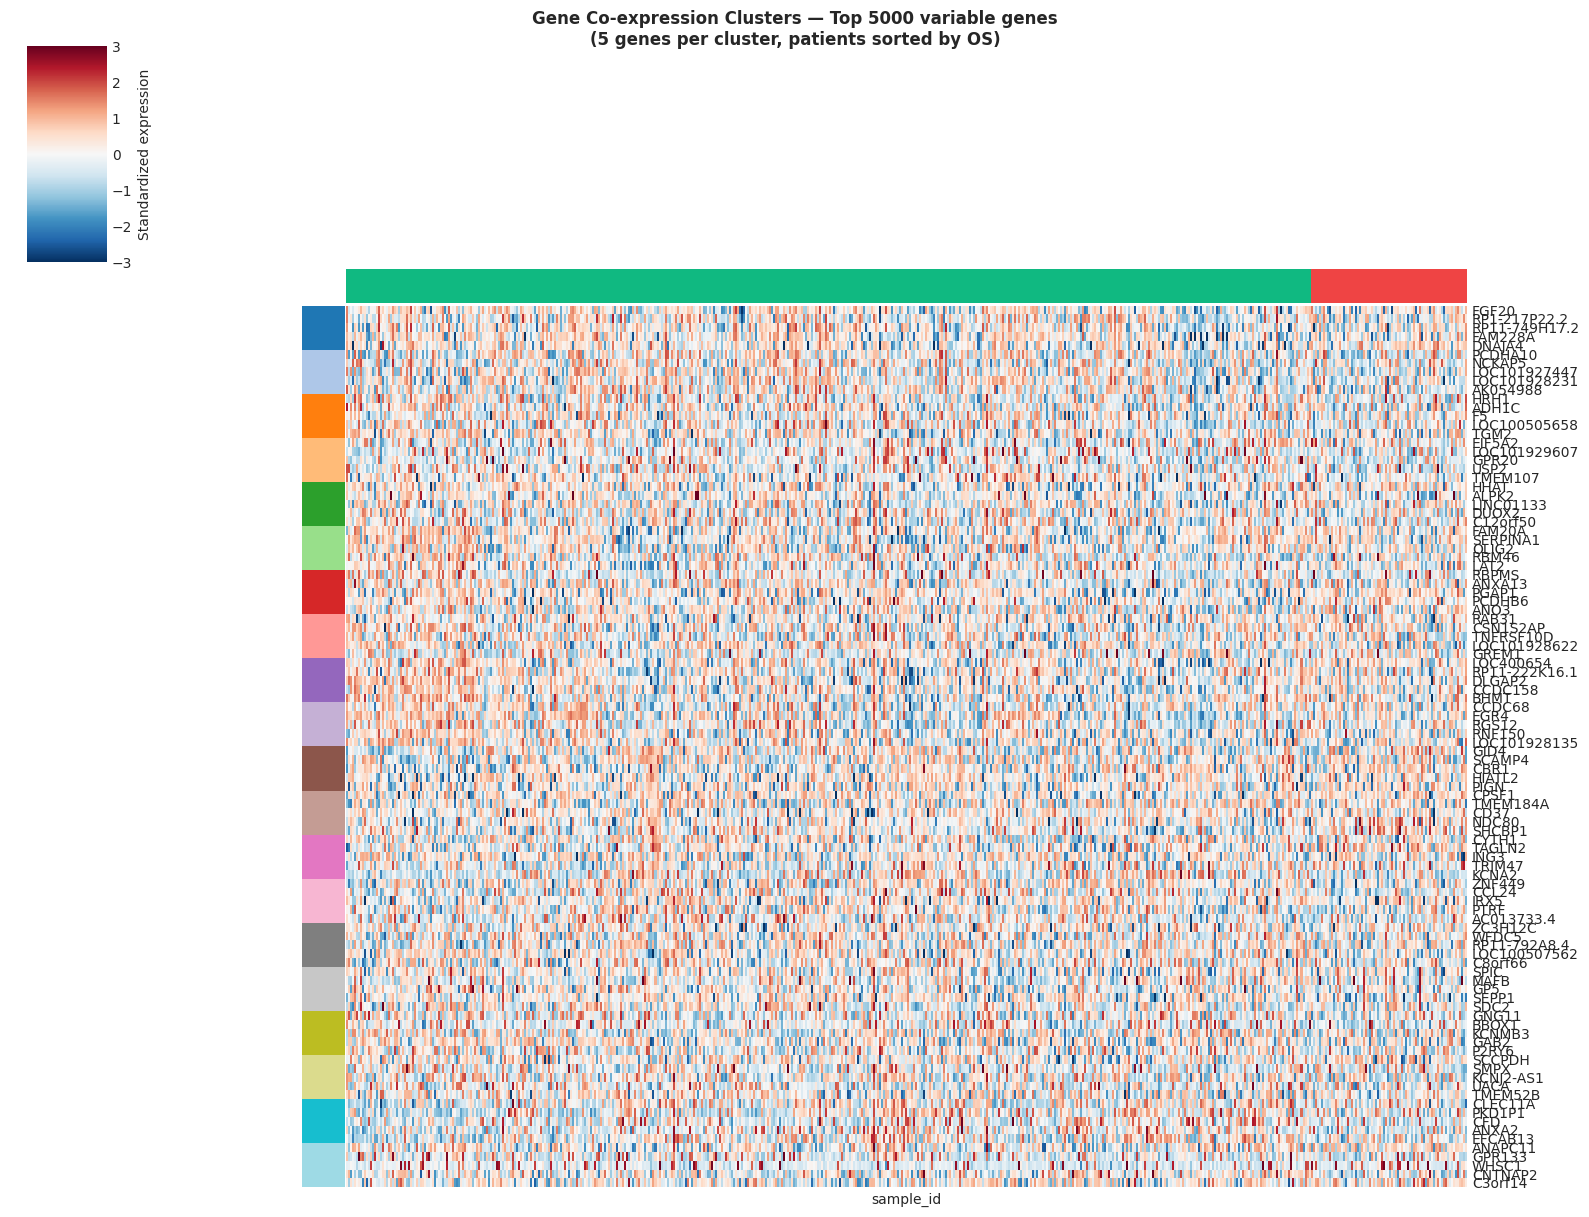

Heatmap saved.


In [12]:
# =============================================================================
# VISUALIZE GENE CLUSTERS — HEATMAP
# =============================================================================
# We visualize a sample of genes from each cluster to see their expression
# patterns across patients. Each row is a gene, each column is a patient.
# Genes within the same cluster should show similar patterns.
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Sample 5 genes per cluster for visualization
sample_genes_per_cluster = []
for cluster_id in range(1, n_clusters + 1):
    cluster_genes = df_gene_clusters[df_gene_clusters['cluster'] == cluster_id]['gene'].values
    n_sample = min(5, len(cluster_genes))
    sampled = np.random.choice(cluster_genes, n_sample, replace=False)
    sample_genes_per_cluster.extend(sampled)

# Sort patients by OS outcome for clearer visualization
patient_order = df_clinical.sort_values('os_24m')['sample_id'].values
df_heatmap = df_top[sample_genes_per_cluster].loc[patient_order].T

# Standardize for visualization
df_heatmap_scaled = pd.DataFrame(
    StandardScaler().fit_transform(df_heatmap.T).T,
    index=df_heatmap.index,
    columns=df_heatmap.columns
)

# Cluster color annotation
cluster_colors = plt.cm.tab20(np.linspace(0, 1, n_clusters))
gene_cluster_map = dict(zip(df_gene_clusters['gene'], df_gene_clusters['cluster']))
row_colors = [cluster_colors[gene_cluster_map[g]-1] for g in df_heatmap_scaled.index]

# Patient OS annotation
os_colors = ['#ef4444' if df_clinical[df_clinical['sample_id'] == s]['os_24m'].values[0] == 1 
             else '#10b981' for s in df_heatmap_scaled.columns]

plt.figure(figsize=(16, 10))
g = sns.clustermap(
    df_heatmap_scaled,
    row_cluster=False,
    col_cluster=False,
    row_colors=row_colors,
    col_colors=os_colors,
    cmap='RdBu_r',
    center=0,
    vmin=-3, vmax=3,
    xticklabels=False,
    yticklabels=True,
    figsize=(16, 12),
    cbar_kws={'label': 'Standardized expression'}
)
g.fig.suptitle('Gene Co-expression Clusters — Top 5000 variable genes\n(5 genes per cluster, patients sorted by OS)',
               fontsize=12, fontweight='bold', y=1.01)
plt.savefig('../notebooks/gene_clusters_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Heatmap saved.")

In [13]:
# =============================================================================
# GENE CLUSTER CHARACTERIZATION
# =============================================================================
# For each cluster, compute the mean expression profile across all patients
# and correlate it with OS and EFS outcomes.
# This tells us which clusters are associated with survival.
# =============================================================================

# Compute mean expression per cluster per patient
cluster_profiles = {}
for cluster_id in range(1, n_clusters + 1):
    cluster_genes = df_gene_clusters[df_gene_clusters['cluster'] == cluster_id]['gene'].values
    cluster_profiles[f'cluster_{cluster_id}'] = df_top[cluster_genes].mean(axis=1)

df_cluster_profiles = pd.DataFrame(cluster_profiles)
df_cluster_profiles.index.name = 'sample_id'
df_cluster_profiles = df_cluster_profiles.reset_index()
df_cluster_profiles = df_cluster_profiles.merge(df_clinical[['sample_id', 'os_24m', 'efs_24m']], on='sample_id')

# Correlate each cluster with OS and EFS
print("=== CLUSTER CORRELATION WITH SURVIVAL OUTCOMES ===\n")
correlations = []
for cluster in [f'cluster_{i}' for i in range(1, n_clusters + 1)]:
    corr_os = df_cluster_profiles[cluster].corr(df_cluster_profiles['os_24m'])
    corr_efs = df_cluster_profiles[cluster].corr(df_cluster_profiles['efs_24m'])
    correlations.append({'cluster': cluster, 'corr_os': corr_os, 'corr_efs': corr_efs})

df_corr = pd.DataFrame(correlations).sort_values('corr_os', key=abs, ascending=False)
print(df_corr.to_string(index=False))

=== CLUSTER CORRELATION WITH SURVIVAL OUTCOMES ===

   cluster   corr_os  corr_efs
cluster_12  0.223737  0.272188
cluster_15 -0.122581 -0.169218
cluster_14 -0.107634 -0.093444
cluster_11  0.100030  0.091350
 cluster_2 -0.098999 -0.081318
cluster_20  0.092971  0.084409
cluster_19 -0.086576 -0.095491
 cluster_4 -0.082603 -0.070837
cluster_18  0.071927  0.094290
cluster_17 -0.070370 -0.093958
 cluster_1 -0.067295 -0.048256
 cluster_3 -0.043804 -0.040543
cluster_16 -0.039287 -0.108297
 cluster_8 -0.032154 -0.070118
cluster_13 -0.021994 -0.088271
 cluster_6  0.015437  0.006952
 cluster_9  0.009227  0.007939
 cluster_7  0.004580 -0.000465
 cluster_5 -0.001354  0.027177
cluster_10 -0.000348  0.005805


In [14]:
# =============================================================================
# INSPECT CLUSTER 12 — TOP SURVIVAL-ASSOCIATED CLUSTER
# =============================================================================

cluster12_genes = df_gene_clusters[df_gene_clusters['cluster'] == 12]['gene'].values
print(f"Cluster 12 — {len(cluster12_genes)} genes")
print(f"Correlation with OS: 0.224 | EFS: 0.272")
print(f"\nGenes in cluster 12:")
print(sorted(cluster12_genes))

Cluster 12 — 127 genes
Correlation with OS: 0.224 | EFS: 0.272

Genes in cluster 12:
['AC004941.5', 'AK9', 'AKNA', 'ANKLE1', 'ATAD2', 'BC022047', 'BIRC5', 'BMP8B', 'BPNT1', 'BRIP1', 'C17orf70', 'C1orf112', 'C9orf66', 'CCDC132', 'CCNB2', 'CD37', 'CDC20', 'CDCA5', 'CDK1', 'CDKN2C', 'CDKN3', 'CELSR3', 'CENPE', 'CENPK', 'CENPM', 'CEP128', 'CEP290', 'CEP55', 'CGREF1', 'CLIC2', 'COL4A4', 'COLGALT1', 'CPSF1', 'CRIP1', 'CTA-292E10.6', 'DEPDC1B', 'DYM', 'EMC3-AS1', 'FABP5', 'FAM111B', 'FOXM1', 'GALNT12', 'GEN1', 'GINS2', 'GSDMB', 'GSTZ1', 'HELLS', 'HIPK1', 'HIST1H1C', 'HIST1H2AC', 'HIST1H2AJ', 'HIST1H2BB', 'HIST1H2BC', 'HPDL', 'IKBIP', 'IL6R', 'KIF18A', 'KIF20A', 'KIF23', 'KIFC1', 'LOC100129917', 'LOC100289092', 'LOC100506282', 'LOC100996756', 'LOC101060510', 'LOC101928433', 'LRRC1', 'LY6E', 'MAGEC2', 'MAP2K5', 'MATR3', 'MCM10', 'MED6', 'MEF2D', 'MIR142', 'MIR34A', 'MNX1', 'MYC', 'NBR2', 'NCAPH', 'NDC80', 'NEK2', 'NIT1', 'NUF2', 'NUP153', 'PLEC', 'PLK4', 'POLE2', 'PRKD3', 'PRMT7', 'PRR15', 'PSM

In [15]:
# =============================================================================
# CLUSTER 12 — BIOLOGICAL INTERPRETATION
# =============================================================================
# Cluster 12 is the most strongly associated with poor survival outcomes
# (corr OS: 0.224, corr EFS: 0.272). It contains 127 genes that form a
# coherent TUMOR PROLIFERATION SIGNATURE:
#
# Key oncogenes and cell cycle drivers:
#   - MYC: master oncogene, one of the most important in MM
#   - CDK1, CCNB2: cell cycle kinases and cyclins
#   - BIRC5 (Survivin): apoptosis inhibitor, poor prognosis marker in MM
#   - FOXM1: proliferation transcription factor, associated with drug resistance
#   - NEK2: mitotic kinase, associated with bortezomib resistance in MM
#   - RRM2: ribonucleotide reductase, previously identified as MM biomarker
#
# Mitotic spindle and DNA replication machinery:
#   - CDC20, CENPE, CENPK, NDC80, NUF2, KIF18A, KIF20A, KIF23
#   - MCM10, GINS2, POLE2, BRIP1, UHRF1
#
# Biological interpretation:
#   Patients with high expression of cluster 12 genes have tumors that are
#   proliferating faster, leading to worse survival outcomes. This is a
#   well-established finding in MM genomics and validates the quality of
#   the dataset and analysis.
#
# This cluster will be a priority target for SHAP analysis in notebook 04.
# =============================================================================
print("Cluster 12 biological interpretation documented.")

Cluster 12 biological interpretation documented.


In [16]:
# =============================================================================
# INSPECT CLUSTER 15 — PROTECTIVE CLUSTER (negative correlation with OS)
# =============================================================================

cluster15_genes = df_gene_clusters[df_gene_clusters['cluster'] == 15]['gene'].values
print(f"Cluster 15 — {len(cluster15_genes)} genes")
print(f"Correlation with OS: -0.123 | EFS: -0.169")
print(f"\nGenes in cluster 15:")
print(sorted(cluster15_genes))

Cluster 15 — 199 genes
Correlation with OS: -0.123 | EFS: -0.169

Genes in cluster 15:
['ABCC3', 'ABCG1', 'ADSS', 'AGR2', 'ALDH2', 'ALOX5AP', 'AMER1', 'ARHGAP19', 'ARNTL2', 'ASB5', 'ATP6V0D2', 'ATXN8OS', 'BAI3', 'BC034416', 'BC045789', 'BREA2', 'C15orf62', 'C19orf81', 'C20orf203', 'C21orf58', 'C3orf35', 'C8orf66', 'CADM4', 'CALHM3', 'CCDC169', 'CCND1', 'CD4', 'CD79A', 'CECR2', 'CELA2B', 'CHGA', 'CHI3L1', 'CHN2', 'CLDN10-AS1', 'COL3A1', 'COLQ', 'COX18', 'CPVL', 'CTD-2292M16.8', 'CTD-2540F13.2', 'CXCR5', 'DCC', 'DCLK1', 'DDX60', 'DDX60L', 'DISP2', 'DKFZp434L192', 'DNASE2B', 'DNTT', 'DPPA2', 'DPPA5', 'DUSP6', 'EDNRB', 'EID3', 'EIF1AY', 'ENAH', 'ENTPD1', 'ERVH-6', 'EXOG', 'FAM19A5', 'FHAD1', 'FLJ12825', 'FLJ16779', 'FMNL3', 'FMO3', 'FTCDNL1', 'GAS2L2', 'GBP5', 'GCNT2', 'GCNT3', 'GDF11', 'GJB2', 'GMDS', 'GPHA2', 'GRIN2A', 'HBM', 'HEPH', 'HEY1', 'HOXB2', 'HPR', 'IFI44L', 'IGHG1', 'IGKC', 'IGSF22', 'Igk', 'KCNAB3', 'KCNMB2', 'KCNN4', 'KDM5D', 'LAMA4', 'LINC00925', 'LINC00944', 'LINC00996', 'L

In [17]:
# =============================================================================
# CLUSTER 15 — BIOLOGICAL INTERPRETATION
# =============================================================================
# Cluster 15 is negatively correlated with poor survival outcomes
# (corr OS: -0.123, corr EFS: -0.169) — higher expression = better survival.
#
# Three biological components explain this cluster:
#
# 1. SEX EFFECT (chromosome Y genes):
#    EIF1AY, KDM5D, RPS4Y1, USP9Y, ZFY, TXLNGY
#    Male patients express these genes — if males have better prognosis in
#    this cohort, it would drive the negative correlation with OS.
#    These genes should be treated as confounders in modeling.
#
# 2. IMMUNE ACTIVITY (protective):
#    CD4, CD79A, CXCR5, SYK, TLR3, TLR8, SLAMF8, RGS13
#    Tumors with higher immune infiltration (T cells, B cells, NK cells)
#    tend to have better outcomes — consistent with immunotherapy literature.
#
# 3. MM MOLECULAR SUBTYPE:
#    CCND1: cyclin D1 — defines the t(11;14) MM subtype, which is associated
#    with better prognosis compared to other MM subtypes.
#    EDNRB: previously identified as highly variable — appears here as
#    potentially protective, worth investigating further in SHAP analysis.
#
# Action: separate chromosome Y genes from immune/subtype genes before
# modeling to avoid confounding sex effect with biological signal.
# =============================================================================
print("Cluster 15 biological interpretation documented.")

Cluster 15 biological interpretation documented.


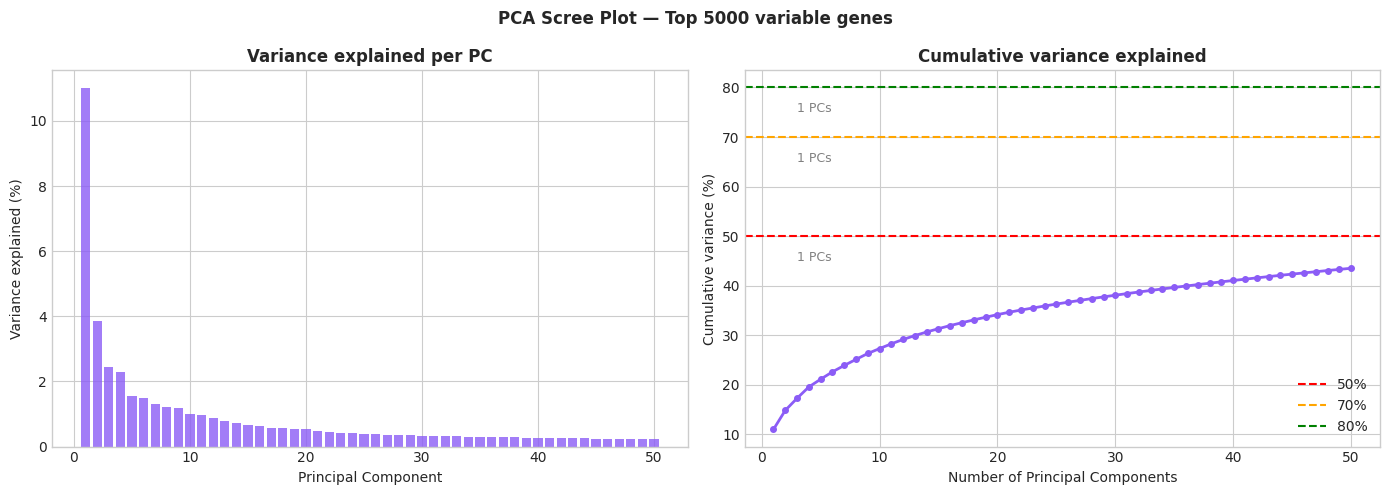


Variance thresholds:
  50% variance: 1 PCs needed
  70% variance: 1 PCs needed
  80% variance: 1 PCs needed
  90% variance: 1 PCs needed


In [18]:
# =============================================================================
# PCA SCREE PLOT — OPTIMAL NUMBER OF COMPONENTS
# =============================================================================
# The scree plot shows the variance explained by each PC.
# We look for the "elbow" — the point where adding more PCs gives
# diminishing returns.
# =============================================================================

pca_full = PCA(n_components=50, random_state=42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance per PC
axes[0].bar(range(1, 51), pca_full.explained_variance_ratio_ * 100,
            color='#8b5cf6', alpha=0.8)
axes[0].set_title('Variance explained per PC', fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance explained (%)')

# Cumulative variance
axes[1].plot(range(1, 51), cumvar * 100, color='#8b5cf6', linewidth=2, marker='o', markersize=4)
axes[1].axhline(y=50, color='red', linestyle='--', label='50%')
axes[1].axhline(y=70, color='orange', linestyle='--', label='70%')
axes[1].axhline(y=80, color='green', linestyle='--', label='80%')
axes[1].set_title('Cumulative variance explained', fontweight='bold')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative variance (%)')
axes[1].legend()

# Annotate key thresholds
for threshold in [50, 70, 80]:
    n_pcs = np.argmax(cumvar >= threshold/100) + 1
    axes[1].annotate(f'{n_pcs} PCs', 
                     xy=(n_pcs, threshold),
                     xytext=(n_pcs + 2, threshold - 5),
                     fontsize=9, color='gray')

plt.suptitle('PCA Scree Plot — Top 5000 variable genes', fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVariance thresholds:")
for threshold in [50, 70, 80, 90]:
    n_pcs = np.argmax(cumvar >= threshold/100) + 1
    print(f"  {threshold}% variance: {n_pcs} PCs needed")
    

In [20]:
# =============================================================================
# PCA CONCLUSIONS AND NEXT STEPS
# =============================================================================
# PCA FINDINGS:
#   - PC1 (11%) is the dominant component but captures a mix of biological
#     and technical variation rather than a clear survival signal
#   - The cumulative variance curve never reaches 50% in the first 50 PCs,
#     indicating that variance is highly distributed across thousands of
#     components — typical of high-dimensional genomic data
#   - No clear separation between surviving and deceased patients in PC1/PC2
#   - Cluster analysis revealed more meaningful structure than PCA:
#     * Cluster 12 (proliferation signature) positively correlated with OS
#     * Cluster 15 (immune activity + sex effect) negatively correlated with OS
#
# LIMITATION OF PCA FOR THIS DATASET:
#   PCA is a global linear method — it finds the directions of maximum
#   variance regardless of their association with survival. In genomic data,
#   the survival signal is often distributed across many genes and pathways,
#   making PCA suboptimal for feature extraction in survival prediction.
#
# NEXT STEPS — TWO PARALLEL MODELING STRATEGIES:
#
#   Strategy A — Cluster scores (20 features):
#     Use the mean expression of each of the 20 gene clusters as features.
#     Biologically interpretable — each feature represents a pathway.
#     Simpler model, easier to explain with SHAP.
#
#   Strategy B — LASSO feature selection:
#     Use LASSO regression to select genes directly associated with survival.
#     More granular — features are individual genes.
#     Potentially more powerful but less interpretable at pathway level.
#
#   Both strategies will be compared on the predefined Validation set
#   and explained with SHAP to identify the most important predictors
#   of survival in Multiple Myeloma.
# =============================================================================
print("PCA conclusions documented.")

PCA conclusions documented.


In [19]:
# =============================================================================
# DIMENSIONALITY REDUCTION — UMAP
# =============================================================================
# UMAP (Uniform Manifold Approximation and Projection) is a non-linear
# dimensionality reduction technique that preserves local structure better
# than PCA. Unlike PCA which finds linear combinations of genes, UMAP
# finds a low-dimensional representation that preserves the neighborhood
# relationships between patients.
#
# Key difference vs PCA:
#   - PCA: linear, maximizes global variance
#   - UMAP: non-linear, preserves local neighborhood structure
#   - UMAP is better at revealing clusters and non-linear patterns
#
# We use the same top 5000 variable genes and the PCA-reduced space
# (50 PCs) as input to UMAP for efficiency.
# =============================================================================

# Install umap if needed
try:
    import umap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'umap-learn'])
    import umap

print("Computing UMAP... (this may take a few minutes)")

# Use PCA-reduced space as input (faster and less noisy)
X_pca_50 = pca_full.transform(X_scaled)

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X_pca_50)

print("UMAP computed ✅")
print(f"UMAP output shape: {X_umap.shape}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [umap-learn]
Computing UMAP... (this may take a few minutes)
UMAP computed ✅
UMAP output shape: (559, 2)


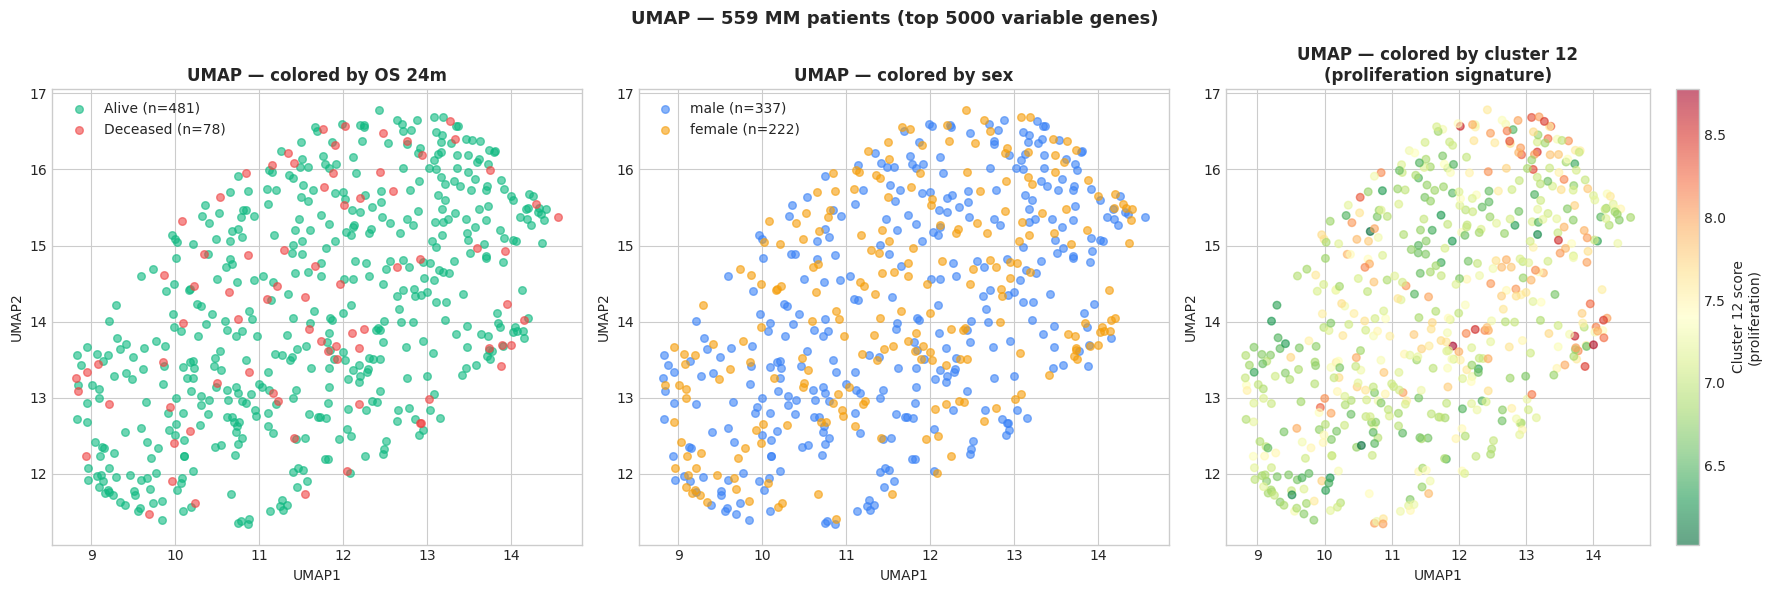

In [21]:
# =============================================================================
# UMAP VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Merge UMAP results with clinical data
df_umap = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2'])
df_umap['sample_id'] = df_expr.index
df_umap = df_umap.merge(df_clinical, on='sample_id')

# Add cluster 12 score
cluster12_genes = df_gene_clusters[df_gene_clusters['cluster'] == 12]['gene'].values
df_umap['cluster12_score'] = df_expr[cluster12_genes].mean(axis=1).values

# 1. Color by OS outcome
for outcome, color, label in [(0, '#10b981', 'Alive'), (1, '#ef4444', 'Deceased')]:
    mask = df_umap['os_24m'] == outcome
    axes[0].scatter(df_umap[mask]['UMAP1'], df_umap[mask]['UMAP2'],
                   c=color, alpha=0.6, s=30, label=f"{label} (n={mask.sum()})")
axes[0].set_title('UMAP — colored by OS 24m', fontweight='bold')
axes[0].set_xlabel('UMAP1')
axes[0].set_ylabel('UMAP2')
axes[0].legend()

# 2. Color by sex
for sex, color in [('male', '#3b82f6'), ('female', '#f59e0b')]:
    mask = df_umap['sex'] == sex
    axes[1].scatter(df_umap[mask]['UMAP1'], df_umap[mask]['UMAP2'],
                   c=color, alpha=0.6, s=30, label=f"{sex} (n={mask.sum()})")
axes[1].set_title('UMAP — colored by sex', fontweight='bold')
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')
axes[1].legend()

# 3. Color by cluster 12 score
scatter = axes[2].scatter(df_umap['UMAP1'], df_umap['UMAP2'],
                          c=df_umap['cluster12_score'], cmap='RdYlGn_r',
                          alpha=0.6, s=30)
plt.colorbar(scatter, ax=axes[2], label='Cluster 12 score\n(proliferation)')
axes[2].set_title('UMAP — colored by cluster 12\n(proliferation signature)', fontweight='bold')
axes[2].set_xlabel('UMAP1')
axes[2].set_ylabel('UMAP2')

plt.suptitle('UMAP — 559 MM patients (top 5000 variable genes)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/umap_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# =============================================================================
# UMAP — INTERPRETATION
# =============================================================================
# UMAP (Uniform Manifold Approximation and Projection) is a non-linear
# dimensionality reduction technique that compresses the 5000-gene expression
# profile of each patient into 2 dimensions, preserving neighborhood
# relationships. Two patients close together in the UMAP plot have similar
# gene expression profiles; two patients far apart are molecularly different.
#
# Unlike PCA, UMAP axes have no biological interpretation — only the relative
# distances and groupings between points are meaningful.
#
# FINDINGS:
#
# Plot 1 — OS 24m:
#   Deceased patients (red) are distributed throughout the entire point cloud
#   with no concentration in any specific region. Survival outcome does not
#   define discrete molecular subgroups — the prognostic signal is weak and
#   distributed across many genes rather than concentrated in a molecular
#   subtype. This is consistent with the PCA findings.
#
# Plot 2 — Sex:
#   Male and female patients are completely mixed with no separation by sex.
#   Despite XIST and EIF1AY appearing as highly variable genes, the sex
#   effect is not strong enough to create distinct molecular subgroups in
#   the context of the overall tumor expression profile.
#
# Plot 3 — Cluster 12 (proliferation signature):
#   This is the most informative plot. A clear gradient is visible — patients
#   with high cluster 12 scores (red, high proliferation) tend to concentrate
#   in the upper right region of the plot, while low-proliferation patients
#   (green) concentrate in the lower left. This confirms that the proliferation
#   signature of cluster 12 partially defines the molecular structure of the
#   dataset and validates its relevance as a feature for survival modeling.
#
# OVERALL CONCLUSION:
#   The dataset does not show strongly discrete molecular subtypes — it is
#   a continuous cloud. However, the cluster 12 gradient confirms a meaningful
#   biological structure that will be exploited in the modeling notebook.
#   The two parallel modeling strategies (cluster scores vs LASSO gene
#   selection) will attempt to capture this distributed survival signal.
# =============================================================================
print("UMAP interpretation documented.")

UMAP interpretation documented.
